In [7]:
import os

# Install the Kaggle API client
!pip install kaggle

In [10]:
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_d48c4fab5ba2cc09f8e7c4e8de4ffd4b'
os.environ['KAGGLE_USERNAME'] = 'robstark143' # Replace 'YOUR_KAGGLE_USERNAME' with your actual Kaggle username

In [11]:
# Create the .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Create the kaggle.json file with your API token and username
# Ensure these environment variables are correctly set in the previous cell
kaggle_json_content = f'{{"username":"{os.environ.get("KAGGLE_USERNAME")}","key":"{os.environ.get("KAGGLE_API_TOKEN")}"}}'
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_json_content)

# Set permissions for the kaggle.json file (read/write for owner only)
!chmod 600 ~/.kaggle/kaggle.json

print("kaggle.json created and permissions set.")

kaggle.json created and permissions set.


In [12]:
# Download the specified dataset
!kaggle datasets download -d kaushil268/disease-prediction-using-machine-learning

# List files in your Kaggle directory to see the downloaded zip file
!ls

Dataset URL: https://www.kaggle.com/datasets/kaushil268/disease-prediction-using-machine-learning
License(s): DbCL-1.0
  0% 0.00/29.8k [00:00<?, ?B/s]
100% 29.8k/29.8k [00:00<00:00, 71.1MB/s]
disease-prediction-using-machine-learning.zip  sample_data


In [13]:
# Unzip the downloaded dataset
!unzip -o disease-prediction-using-machine-learning.zip

# List files again to see the extracted CSV files
!ls

Archive:  disease-prediction-using-machine-learning.zip
  inflating: Testing.csv             
  inflating: Training.csv            
disease-prediction-using-machine-learning.zip  Testing.csv
sample_data				       Training.csv


In [15]:
import warnings
warnings.filterwarnings("ignore")

In [16]:
import numpy as np
import pandas as pd
from scipy.stats import mode
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

%matplotlib inline

In [17]:
data_path = "/content/Training.csv"

data = pd.read_csv(data_path)

#data.head()

# Reading the train.csv by removing the
# last column since it's an empty column
data = pd.read_csv(data_path).dropna(axis=1)
data.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


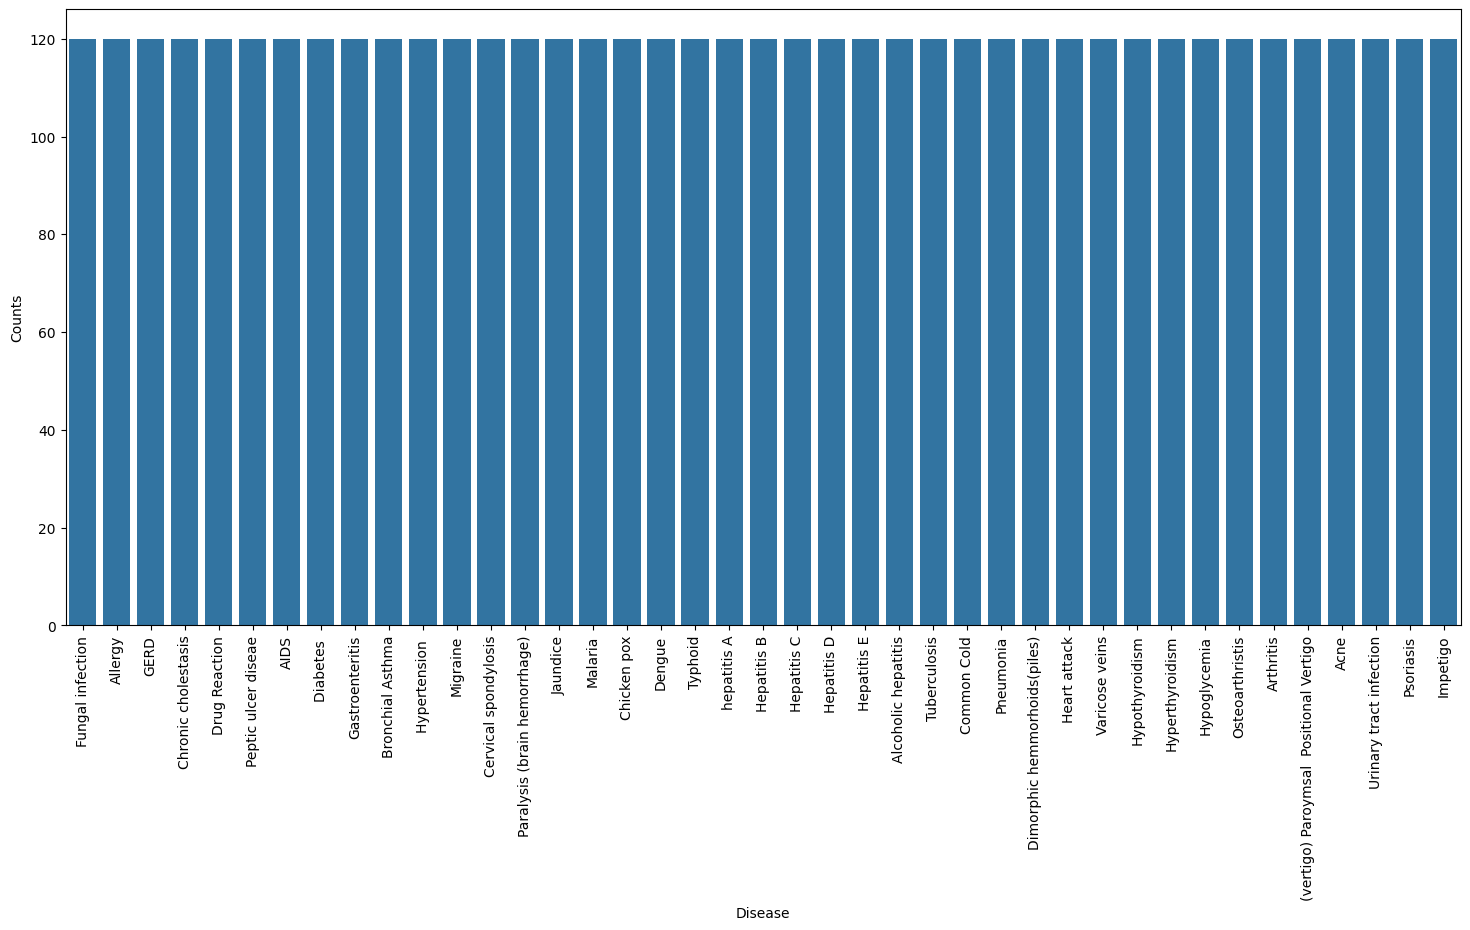

In [18]:
# checking whether the dataset is balanced or not
disease_counts = data['prognosis'].value_counts()

temp_df = pd.DataFrame({
    "Disease": disease_counts.index,
    "Counts": disease_counts.values
})


plt.figure(figsize=(18,8))
sns.barplot(x='Disease', y = 'Counts' , data=temp_df)
plt.xticks(rotation=90)
plt.show()

In [19]:
# Encoding the target value into numerical values
#using LabelEncoder

encoder = LabelEncoder()
data['prognosis'] = encoder.fit_transform(data['prognosis'])

In [20]:
test_data_path = '/content/Testing.csv'

#dropping the null column
test_data = pd.read_csv(test_data_path).dropna(axis=1)
test_data.head()


#encoding the target value
test_data['prognosis'] = encoder.fit_transform(test_data['prognosis'])

In [21]:
X = data.iloc[:,:-1]
y = data.iloc[:, -1]
X_train, X_test, y_train, y_test =train_test_split(
  X, y, test_size = 0.2, random_state = 24)

print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Test: {X_test.shape}, {y_test.shape}")

Train: (3936, 132), (3936,)
Test: (984, 132), (984,)


In [22]:
# Defining scoring metric for k-fold cross validation
def cv_scoring(estimator, X, y):
    return accuracy_score(y, estimator.predict(X))

# Initializing Models
models = {
    "SVC":SVC(),
    "Gaussian NB":GaussianNB(),
    "Random Forest":RandomForestClassifier(random_state=18)
}

# Producing cross validation score for the models
for model_name in models:
    model = models[model_name]
    scores = cross_val_score(model, X, y, cv = 10,
                             n_jobs = -1,
                             scoring = cv_scoring)
    print("=="*30)
    print(model_name)
    print(f"Scores: {scores}")
    print(f"Mean Score: {np.mean(scores)}")

SVC
Scores: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Mean Score: 1.0
Gaussian NB
Scores: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Mean Score: 1.0
Random Forest
Scores: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Mean Score: 1.0


Accuracy on train data by SVM Classifier: 100.0
Accuracy on test data by SVM Classifier: 100.0


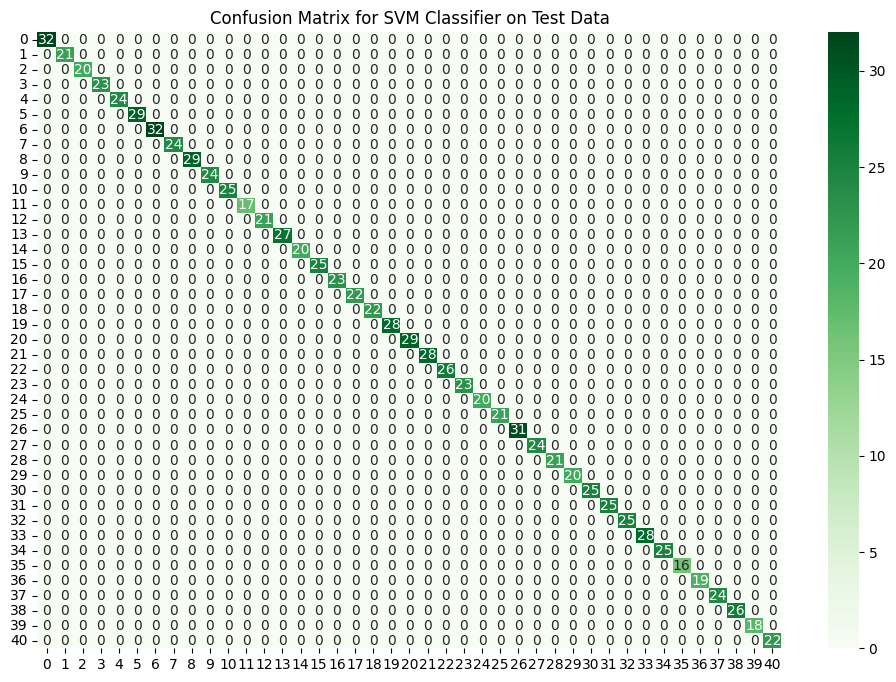

In [43]:
# Training and testing SVM Classifier
svm_model = SVC()
svm_model.fit(X_train, y_train)
preds = svm_model.predict(X_test)

print(f"Accuracy on train data by SVM Classifier\
: {accuracy_score(y_train, svm_model.predict(X_train))*100}")

print(f"Accuracy on test data by SVM Classifier\
: {accuracy_score(y_test, preds)*100}")
cf_matrix = confusion_matrix(y_test, preds)
plt.figure(figsize=(12,8))
sns.heatmap(cf_matrix, annot=True, cmap='Greens')
plt.title("Confusion Matrix for SVM Classifier on Test Data")
plt.show()

Accuracy on train data by Naive Bayes Classifier: 100.0
Accuracy on test data by Naive Bayes Classifier: 100.0


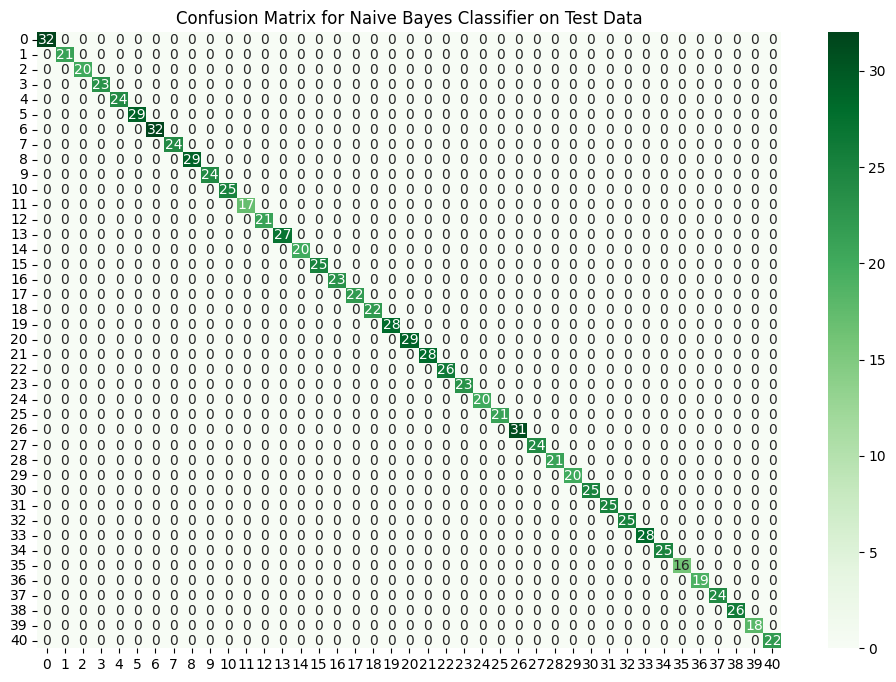

In [44]:
# Training and testing Naive Bayes Classifier
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
preds = nb_model.predict(X_test)
print(f"Accuracy on train data by Naive Bayes Classifier\
: {accuracy_score(y_train, nb_model.predict(X_train))*100}")

print(f"Accuracy on test data by Naive Bayes Classifier\
: {accuracy_score(y_test, preds)*100}")
cf_matrix = confusion_matrix(y_test, preds)
plt.figure(figsize=(12,8))
sns.heatmap(cf_matrix, annot=True, cmap='Greens')
plt.title("Confusion Matrix for Naive Bayes Classifier on Test Data")
plt.show()

Accuracy on train data by Random Forest Classifier: 100.0
Accuracy on test data by Random Forest Classifier: 100.0


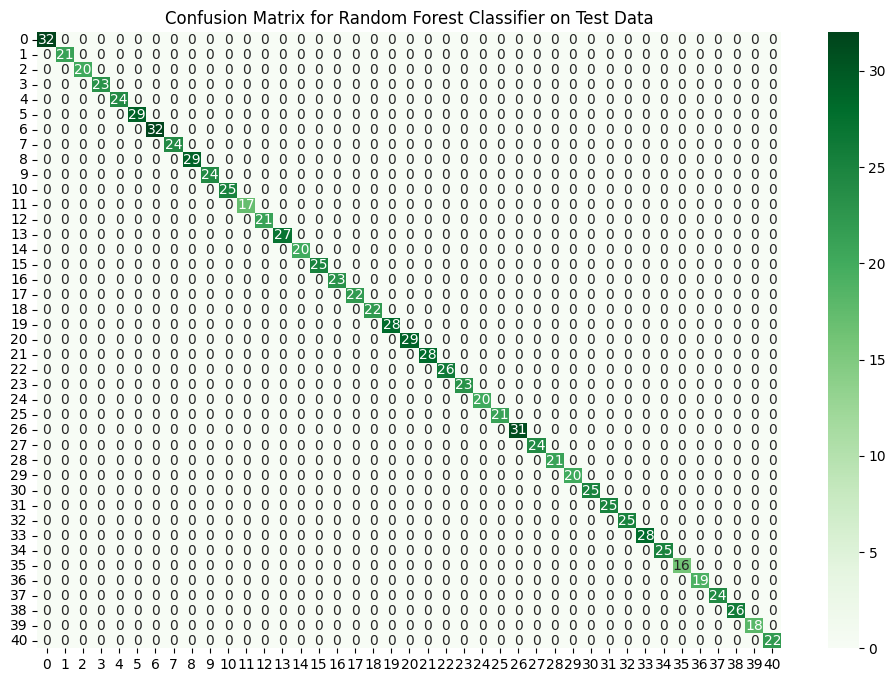

In [45]:
# Training and testing Random Forest Classifier
rf_model = RandomForestClassifier(random_state=18)
rf_model.fit(X_train, y_train)
preds = rf_model.predict(X_test)
print(f"Accuracy on train data by Random Forest Classifier\
: {accuracy_score(y_train, rf_model.predict(X_train))*100}")

print(f"Accuracy on test data by Random Forest Classifier\
: {accuracy_score(y_test, preds)*100}")

cf_matrix = confusion_matrix(y_test, preds)
plt.figure(figsize=(12,8))
sns.heatmap(cf_matrix, annot=True, cmap='Greens')
plt.title("Confusion Matrix for Random Forest Classifier on Test Data")
plt.show()

Accuracy on Test dataset by the combined model: 100.0


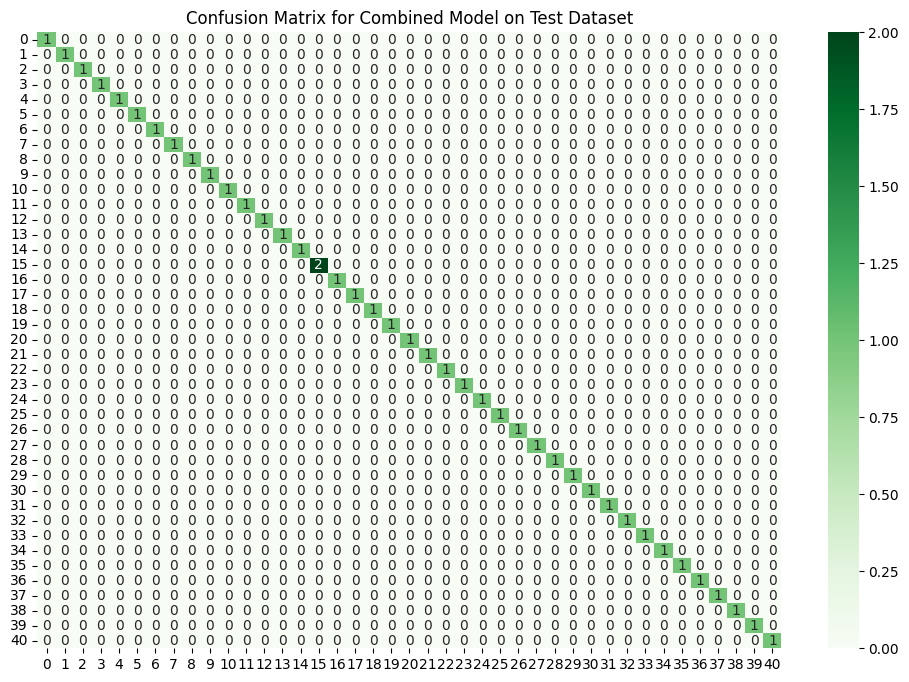

In [46]:
# Training the models on whole data
final_svm_model = SVC()
final_nb_model = GaussianNB()
final_rf_model = RandomForestClassifier(random_state=18)
final_svm_model.fit(X, y)
final_nb_model.fit(X, y)
final_rf_model.fit(X, y)

# Reading the test data
test_data = pd.read_csv("/content/Testing.csv").dropna(axis=1)

test_X = test_data.iloc[:, :-1]
test_Y = encoder.transform(test_data.iloc[:, -1])

# Making prediction by take mode of predictions
# made by all the classifiers
svm_preds = final_svm_model.predict(test_X)
nb_preds = final_nb_model.predict(test_X)
rf_preds = final_rf_model.predict(test_X)

#!pip install scipy
from scipy import stats

final_preds = [stats.mode([i,j,k])[0] for i,j,k in zip(svm_preds, nb_preds, rf_preds)]

print(f"Accuracy on Test dataset by the combined model: {accuracy_score(test_Y, final_preds)*100}")

cf_matrix = confusion_matrix(test_Y, final_preds)
plt.figure(figsize=(12,8))

sns.heatmap(cf_matrix, annot = True, cmap='Greens')
plt.title("Confusion Matrix for Combined Model on Test Dataset")
plt.show()

In [32]:
symptoms = X.columns.values

#Creating a symptom index dictionary to encode the input symptoms into numerical form
symptom_index = {}
for index, value in enumerate(symptoms):
    symptom = " ".join([i.capitalize() for i in value.split("_")])
    symptom_index[symptom] = index

data_dict = {
    "symptom_index": symptom_index,
    "predictions_classes":encoder.classes_
}

#Defining the functions
#Input: string containing symptoms seperated by commas
#Output : Generated predictions by models
def predictDisease(symptoms_input_string):
    symptoms_raw = symptoms_input_string.split(",")

#creating input data for the models
    input_data = [0] * len(data_dict["symptom_index"])
    for symptom_raw in symptoms_raw:
        # Normalize the symptom_raw string to match the keys in symptom_index
        # This handles cases like 'shivering' -> 'Shivering', 'skin rash' -> 'Skin Rash', 'skin_rash' -> 'Skin Rash'
        normalized_symptom = " ".join([word.capitalize() for word in symptom_raw.strip().replace(" ", "_").split("_")])

        if normalized_symptom not in data_dict["symptom_index"]:
            raise ValueError(f"Symptom '{symptom_raw.strip()}' not recognized or incorrectly formatted. Please check spelling. Expected format examples: 'Itching', 'Skin Rash', 'Continuous Sneezing'.")

        index = data_dict["symptom_index"][normalized_symptom]
        input_data[index] = 1

    input_data = np.array(input_data).reshape(1,-1)

#generating individual outputs
    rf_predictions = data_dict["predictions_classes"][final_rf_model.predict(input_data)[0]]
    nb_predictions = data_dict["predictions_classes"][final_nb_model.predict(input_data)[0]]
    svm_predictions = data_dict["predictions_classes"][final_svm_model.predict(input_data)[0]]

#making final predictions by taking mode of all predictions
#Use statistics.mode instead of scipy.stats.mode
    import statistics
    final_predictions = statistics.mode([rf_predictions, nb_predictions, svm_predictions])
    predictions = {
        "rf_model_prediction": rf_predictions,
        "naive_bayes_prediction": nb_predictions,
        "svm_model_prediction":svm_predictions,
        "final_prediction": final_predictions
    }
    return predictions


#testing the function
print(predictDisease("Itching,Skin Rash,Nodal Skin Eruptions"))

{'rf_model_prediction': 'Fungal infection', 'naive_bayes_prediction': 'Fungal infection', 'svm_model_prediction': 'Fungal infection', 'final_prediction': 'Fungal infection'}


You can use the cell below to test the disease prediction model. Enter symptoms as a comma-separated string (e.g., 'Itching,Skin Rash,Nodal Skin Eruptions'). Make sure the symptoms are capitalized and correctly spelled as they appear in the `symptom_index` dictionary.

In [36]:
# Get symptoms input from the user
user_symptoms = input("Enter symptoms separated by commas (e.g., Itching,Skin Rash): ")

# Make predictions
predictions = predictDisease(user_symptoms)

# Display the predictions
print("\n--- Disease Predictions ---")
for model, prediction in predictions.items():
    print(f"{model.replace('_', ' ').title()}: {prediction}")

Enter symptoms separated by commas (e.g., Itching,Skin Rash): Shivering,Chills

--- Disease Predictions ---
Rf Model Prediction: Allergy
Naive Bayes Prediction: Allergy
Svm Model Prediction: Allergy
Final Prediction: Allergy


In [37]:
import joblib
print("joblib imported successfully.")

joblib imported successfully.


In [38]:
joblib.dump(final_svm_model, 'svm_model.pkl')
joblib.dump(final_nb_model, 'naive_bayes_model.pkl')
joblib.dump(final_rf_model, 'random_forest_model.pkl')
print("Models saved successfully.")

Models saved successfully.
